# Fig 7: GLM to predict deconvolved calcium activity from task and movement variables

Also Extended Data Fig. 9

Implementation of Shih-Yi Tseng's GLM from Chris Harvey lab:  \
https://github.com/sytseng/GLM_Tensorflow_2/tree/main

See a [really nice tutorial](https://github.com/sytseng/GLM_Tensorflow_2/blob/main/tutorial/Tutorial_for_fitting_neural_calcium_imaging_data_with_GLM.ipynb) on the GLM from Shih-Yi.

In [1]:
%matplotlib inline
%load_ext autoreload
%autoreload 2

import math
import sys
import os
import dill
import numpy as np
import scipy as sp
import pandas as pd
import warnings
from tqdm import tqdm
import copy

from matplotlib import pyplot as plt
from matplotlib import cm
import seaborn as sns
sns.set_style("white")

from reward_relative import utilities as ut
from reward_relative import plotUtils as pt
from reward_relative import spatial
from reward_relative import dayData as dd
from reward_relative import circ
from reward_relative import rewardAnalysis as ra
from reward_relative import glmUtils

import sklearn
from sklearn.impute import KNNImputer
from sklearn.preprocessing import SplineTransformer, QuantileTransformer


save_figures = False

In [2]:
sklearn.__version__ # needs to be 1.0.2

'1.0.2'

In [3]:
from sklearn.model_selection import train_test_split, GroupShuffleSplit
import tensorflow as tf
import keras

In [4]:
import sys
sys.path.append("/home/mari/local_repos/2p_repos/GLM_Tensorflow_2/code")
import glm_class as glm

In [5]:
from reward_relative.path_dict_firebird import path_dictionary as path_dict
# options: path_dict_josquin, path_dict_msosamac, path_dict_msosaexternal

In [6]:
path_dict

{'preprocessed_root': '/data/2P',
 'sbx_root': '/mnt/oak/InVivoDA/2P_Data',
 'gdrive_root': '/mnt/gdrive/2P_Data',
 'VR_Data': '/data/2P/VR_Data',
 'git_repo_root': '/home/mari/local_repos/2p_repos',
 'TwoPUtils': '/home/mari/local_repos/2p_repos/TwoPUtils',
 'home': '/home/mari',
 'fig_dir': '/data/2P/fig_scratch'}

In [7]:
# # make a month-year figdir and set fig params

fig_dir = ut.make_fig_dir(path_dict)
pt.set_fig_params(fontsize=12)

/data/2P/fig_scratch/Apr2025


In [ ]:
# GPU needed to train the model!!
# Check version and eager execution state
print("tensorflow version", tf.__version__)
print("keras version", keras.__version__) #tf.keras.__version__ when keras was 2.8.0
print("Eager Execution Enabled:", tf.executing_eagerly())

# Get the number of replicas 
strategy = tf.distribute.MirroredStrategy()
print("Number of replicas:", strategy.num_replicas_in_sync)

# Get available devices
devices = tf.config.experimental.get_visible_devices()
print("Devices:", devices)
print(tf.config.experimental.list_logical_devices('GPU'))

print("GPU Available: ", tf.config.list_physical_devices('GPU'))
print("All Physical Devices", tf.config.list_physical_devices())

# Table of Contents

[Load pre-existing multiDayData](#Load-saved-multiDayData)
\
[GLM](#GLM)



## Load saved multiDayData

If you want to create a new multiDayData, use the notebook Run_dayData_class.ipynb and save the pickle first.

In [8]:
experiment = 'MetaLearn'
exp_days = [3, 5, 7, 8, 10, 12, 14]

max_anim_list = dd.max_anim_list(experiment,exp_days, year='combined')
ts_key = 'dff' # used to find place field peaks

    
dt = "202504"

pkl_name = "m%s-%s_expdays%s_multiDayData_%s_%s.pickle" % (ut.get_mouse_number(max_anim_list[0]),
                                                           ut.get_mouse_number(
                                                               max_anim_list[-1]),
                                                           ut.make_day_tag(
                                                               exp_days),
                                                           ts_key,
                                                           dt)

pkl_path = os.path.join(path_dict['preprocessed_root'],'multiDayData',pkl_name)
print(pkl_path)
multiDayData = dill.load(open(pkl_path,"rb"))


/data/2P/multiDayData/m2-19_expdays3-5-7-8-10-12-14_multiDayData_dff_202504.pickle


## GLM

[Table of contents](#Table-of-Contents)

## Run GLM across animals

In [9]:
# keep a subclass of multiDayData with only what we need
multiDayDataSub = dd.subclass(multiDayData)
multiDayDataSub

{3: <reward_relative.dayData.subclass.<locals>.dayDataReduced at 0x7fcd0c3ba610>,
 5: <reward_relative.dayData.subclass.<locals>.dayDataReduced at 0x7fcd0c3ba580>,
 7: <reward_relative.dayData.subclass.<locals>.dayDataReduced at 0x7fcd0c3ba760>,
 8: <reward_relative.dayData.subclass.<locals>.dayDataReduced at 0x7fcd0c3ba4f0>,
 10: <reward_relative.dayData.subclass.<locals>.dayDataReduced at 0x7fcd0c3ba1f0>,
 12: <reward_relative.dayData.subclass.<locals>.dayDataReduced at 0x7fcd0c3ba700>,
 14: <reward_relative.dayData.subclass.<locals>.dayDataReduced at 0x7fcd0c3ba6d0>}

In [10]:
del multiDayData

In [25]:
## initialize

# include_ans = multiDayDataSub[day].circ_rel_info_switch_an['include_ans']
frac_dev_thr = 0.15 # fraction deviance explained threshold to keep "well-fit" cells
days = [3,5,7,8,10,12,14]
FDE_full_model = {}
FED_pos = {}
FED_null_pos = {}
mean_FED = {}
mean_FED_null = {}
celltype_inds = {}
celltype_FED = {}
celltype_null = {}

task_predictors = ['pos', 'rel_pos','rewarded']
mvt_predictors = ['speed', 'accel', 'licks']
all_predictors = task_predictors + mvt_predictors

# # dir to save and load pickles of the model output
pickle_dir = os.path.join(path_dict['preprocessed_root'],'pickle_scratch') 

In [23]:
all_predictors

['pos', 'rel_pos', 'rewarded', 'speed', 'accel', 'licks']

In [ ]:
# Run the loop through datasets

from datetime import datetime
timestr = datetime.now().strftime("%Y%m%d-%H%M")
plot_example_neurons = False

# Set whether to fit a new model or load saved existing models:
fit_model = False
# Note that when you fit a new model, results may not be _exactly_ the same
# as seen in the paper due to the stochasticity of the train/test splitting
load_saved_model = True
save_model_pkl = False

dt_to_load = '20240621-2308'

for day in days:

    include_ans = multiDayDataSub[day].circ_rel_stats_across_an['include_ans']
    %reset_selective -f multi_anim_sess
    multi_anim_sess = ut.quick_load_multi_anim_sess(day, anim_list=dd.define_anim_list(experiment,
                                                                                day,
                                                                                year='combined'))

    FDE_full_model[day] = {}
    FED_pos[day] = {}
    FED_null_pos[day] = {}
    mean_FED[day] = {}
    mean_FED_null[day] = {}
    celltype_inds[day] = {}
    celltype_FED[day] = {}
    celltype_null[day] = {}

    for an_i, an in enumerate(include_ans):

        print("%s day %d" % (an, day))
        # Create design matrix
        # (you need to acquire this to be able to plot, quantify, and perform the
        # model ablation procedure, even if you're not training the model)
        X, Y, data, group_info, pos_bases, pos_centers, mvt_basis = glmUtils.create_design_matrix(an,
                                                                          multi_anim_sess[an]['sess'],
                                                                          pos_predictors=[
                                                                              'rewarded',
                                                                          ],
                                                                          mvt_predictors=['speed',
                                                                                          'accel',
                                                                                          'licks',
                                                                                          ],
                                                                          n_pos_bases=45,
                                                                          start_pos=0,
                                                                          end_pos=450,
                                                                          lick_smooth_sigma=2,
                                                                          movt_spline='bspline',  # 'bspline' or 'cosine'
                                                                          rel_pos_type='circular',  # or 'linear'
                                                                          use_speed_thr=2,  # or None, or another value
                                                                          )

        group_size = group_info['group_size']
        group_name = group_info['group_name']
        group_ind = group_info['group_ind']

        group_id = data['trials']
        
        # Identify trial types so we train on 85% of each
        omission = ra.get_omission_trials(multi_anim_sess[an]['sess'])
        omission_idx = group_id[np.isin(group_id, omission['trials'])]
        not_omission = group_id[~np.isin(group_id, omission['trials'])]
        not_omission_set0 = not_omission[np.isin(not_omission,
                                                 np.where(
                                                     multi_anim_sess[an]['trial dict']['trial_set0']
                                                 )[0]
                                                 )
                                         ]
        not_omission_set1 = not_omission[np.isin(not_omission,
                                                 np.where(
                                                     multi_anim_sess[an]['trial dict']['trial_set1']
                                                 )[0]
                                                 )
                                         ]

        # Split data into test and train
        X_train, Y_train, X_test, Y_test, trial_id_train, train_idx = glmUtils.split_data_by_trial_type(
            X,
            Y,
            data,
            omission_idx,
            not_omission_set0,
            not_omission_set1,
            train_size=0.85,
            random_state=30)

        # Reset keras states
        tf.keras.backend.clear_session()

        if fit_model:
            # Initialize GLM_CV (here we're only specifying key input arguments; 
            # others are left as default values; see Shih-Yi's documentation for details)
            model_cv = glm.GLM_CV(n_folds=5, auto_split=True, split_by_group=True,
                                  activation='exp', loss_type='poisson',
                                  regularization='group_lasso', lambda_series=10.0 ** np.linspace(-1, -6, 11),
                                  optimizer='adam', learning_rate=1e-2)

            # Fit the GLM_CV on training data
            model_cv.fit(X_train, Y_train, group_idx=trial_id_train,
                         feature_group_size=group_size, verbose=False)

            # Select models based on CV performance
            model_cv.select_model(se_fraction=0., min_lambda=0., make_fig=True)

        elif load_saved_model:
            pred_list = '-'.join(all_predictors)
            model_name = '%s_expday%d_glmfit_%s_%s' % (
                an, day, pred_list, dt_to_load)
            model_cv = dill.load(
                open(os.path.join(pickle_dir, model_name + '.pickle'), "rb"))
        else:
            raise NotImplementedError('You must either fit or load a model')

        # Evaluate model performance on test data
        frac_dev_expl, dev_model, dev_null, dev_expl = model_cv.evaluate(
            X_test, Y_test, make_fig=False)

        FDE_full_model[day][an] = frac_dev_expl
        # Make prediction on test data
        y_pred = model_cv.predict(X_test)  # can also check X_train

        # --- Model evaluation ----

        # Find cells that exceed a fraction deviance explained threshold
        inc_cells = np.where(frac_dev_expl > frac_dev_thr)
        print(
            f'{len(inc_cells[0])}/{len(frac_dev_expl)} cells above frac_dev_expl = {frac_dev_thr}')

        rr_cells = multiDayDataSub[day].reward_rel_cell_ids[an]
        rr_cells_above_thr = rr_cells[np.isin(rr_cells, inc_cells)]
        print(
            f'{len(rr_cells_above_thr)}/{len(rr_cells)}, RR cells above frac_dev_expl thresh')
        top_2_rr = rr_cells_above_thr[
            np.argsort(frac_dev_expl[rr_cells_above_thr], kind='stable')][-2:]

        n_timepoints = y_pred.shape[0]  # 2300
        sampling_freq_hz = multi_anim_sess[an]['sess'].scan_info['frame_rate']

        if plot_example_neurons:
            for i_neuron in top_2_rr:
                fig, ax = plt.subplots(figsize=(16, 3))
                plt.plot(np.arange(n_timepoints)/sampling_freq_hz,
                         Y_test[:n_timepoints, i_neuron]/10, 'k', lw=0.5, label='data')
                plt.plot(np.arange(n_timepoints)/sampling_freq_hz,
                         y_pred[:n_timepoints, i_neuron]/10, 'r', lw=0.75, label='prediction')
                plt.xlabel('Time (sec)')
                plt.ylabel('Deconvolved activity')
                plt.title("m%s day %d, cell %d, FDE %.2f" % (ut.get_mouse_number(an),
                                                             day,
                                                             i_neuron,
                                                             frac_dev_expl[i_neuron]))
                plt.legend()
                # print(f'Fraction deviance explained = {frac_dev_expl[i_neuron]:.2f}')

                save_figures = False
                if save_figures:
                    description = '-'.join(task_predictors.extend(mvt_predictors))
                    pt.savefig(fig, fig_dir, "%s_expday%s_GLM_data-vs-prediction_cell%d_%s" % (
                        an, day, i_neuron, description)
                    )

        # Get group names for all position expanded features
        group_name_pos = group_name.copy()
        [group_name_pos.remove(name) for name in mvt_predictors]

        # Extract all model weights
        all_weights = model_cv.selected_w

        # Save model as pickle
        if save_model_pkl:
            pred_list = '-'.join(all_predictors)
            model_name = '%s_expday%d_glmfit_%s_%s' % (
                an, day, pred_list, timestr)
            save_model = open(os.path.join(
                pickle_dir, model_name + '.pickle'), "wb")
            dill.dump(model_cv, save_model)
            # Close the pickle
            save_model.close()

        # Loop over all groups of position expanded features to compute kernels
        all_tuning_pos = [np.sum(np.expand_dims(pos_bases, axis=2) * all_weights[
            group_ind == group_name.index(this_group_name), :], axis=1)
                          for this_group_name in group_name_pos]
        all_tuning_pos = np.stack(all_tuning_pos, axis=2)
        all_tuning_pos.shape

        group_name_mvt = mvt_predictors.copy()

        # Loop over all groups of b-spline expanded movement variables to compute kernels
        all_tuning_mvt = [np.sum(np.expand_dims(mvt_basis, axis=2) * all_weights[
            group_ind == group_name.index(this_group_name), :], axis=1)
                          for this_group_name in group_name_mvt]
        all_tuning_mvt = np.stack(all_tuning_mvt, axis=2)

        # Extract posF for training data (used in binning)
        posF = data['pos']
        pos_half_width = np.max(np.diff(pos_centers))
        posF_train = data['pos'][train_idx]

        # Compute pointwise null deviance
        null_dev = glm.pointwise_null_deviance(
            Y[train_idx, :], loss_type=model_cv.loss_type)

        # Bin null deviance into position and time bins
        null_dev_pos = glmUtils.pos_binning(null_dev, posF_train,
                                            pos_centers, pos_half_width)

        # Make prediction of X_train (full model) on CV held-out data
        pred_full_cv = model_cv.make_prediction_cv(X_train)

        # Compute pointwise model deviance with the prediction and ground truth Y
        model_dev_full = glm.pointwise_deviance(
            Y_train, pred_full_cv, loss_type=model_cv.loss_type)

        # Bin full model deviance into position and time bins
        model_dev_pos = glmUtils.pos_binning(model_dev_full, posF_train,
                                             pos_centers, pos_half_width)

        # Perform model breakdown (ablation) procedure
        # Prelocate
        all_var = []  # to keep new feature group (variable) names
        # to keep all position binned difference in model deviance for all variables
        all_diff_dev_pos = []
        all_diff_dev_avg = []  # to keep all mean difference in model deviance for all variables

        # Loop over feature groups and perform model breakdown
        for ind, group in enumerate(group_name):
            X_ablated = X_train.copy()
            # For position expanded feature groups
            if 'fPos' in group:
                if 'fPos' == group:
                    all_var.append(group)
                else:
                    all_var.append(group[:-5])
                var_tm = group
                ind_tm = group_name.index(var_tm)
                ablate_ind = [this_ind in [ind, ind_tm]
                              for this_ind in group_ind]
                # ^position expanded feature groups

            # For feature groups that are not position expanded or temporally expanded
            elif 'fPos' not in group:
                all_var.append(group)
                ablate_ind = [this_ind in [ind] for this_ind in group_ind]

            else:
                continue

            # Set ablated features to 0 (you can do random shuffling here instead)
            X_ablated[:, ablate_ind] = 0

            # Make prediction on X_ablated (on CV held-out data)
            this_pred_ablated = model_cv.make_prediction_cv(X_ablated)

            # Compute pointwise deviance for the ablated model
            model_dev_ablated = glm.pointwise_deviance(
                Y[train_idx, :], this_pred_ablated, loss_type=model_cv.loss_type)

            # Compute deviance difference between ablated model and full model
            diff_dev = model_dev_ablated - model_dev_full

            # Take average difference in deviance
            diff_dev_avg = np.mean(diff_dev, axis=0)

            # Compute position-binned difference in deviance
            diff_dev_pos = glmUtils.pos_binning(diff_dev, posF[train_idx],
                                                pos_centers, pos_half_width, )

            all_diff_dev_pos.append(diff_dev_pos)

        all_diff_dev_pos = np.stack(all_diff_dev_pos, axis=2)

        # Compute position-binned explained deviance of the full model (capped by 0)
        expl_dev_pos = np.maximum(null_dev_pos - model_dev_pos, 0)

        # Compute average null deviance and explained deviance (used as normalizing factors in the next steps)
        null_dev_avg = np.mean(null_dev, axis=0)
        expl_dev_avg = np.mean(null_dev - model_dev_full, axis=0)

        # Compute fraction explained deviance i.e. "RELATIVE CONTRIBUTION"
        # (capped by position binned explained deviance,
        # then normalized by average explained deviance)
        frac_expl_dev_pos = np.minimum(
            all_diff_dev_pos, expl_dev_pos[:, :, np.newaxis])/expl_dev_avg[np.newaxis, :, np.newaxis]  # <- original
        # # Cap deviance difference at -1 if needed -- this didn't change anything
        # frac_expl_dev_pos = np.minimum(np.maximum(all_diff_dev_pos,-1),expl_dev_pos[:,:,np.newaxis])/expl_dev_avg[np.newaxis,:,np.newaxis]

        # Compute fraction null deviance (capped by position binned null deviance,
        # then normalized by average null deviance) 
        frac_null_dev_pos = np.minimum(
            all_diff_dev_pos, null_dev_pos[:, :, np.newaxis])/null_dev_avg[np.newaxis, :, np.newaxis]  # <- original
        # # Cap deviance different at -1 if needed -- this didn't change anything
        # frac_null_dev_pos = np.minimum(np.maximum(all_diff_dev_pos,-1),null_dev_pos[:,:,np.newaxis])/null_dev_avg[np.newaxis,:,np.newaxis]

        # Get FED by cell type
        FED_pos[day][an] = frac_expl_dev_pos
        FED_null_pos[day][an] = frac_null_dev_pos

        # Get indices of neurons of celltypes of interest
        celltype_inds[day][an] = {}
        types = ['track', 'nonreward_remap']
        for t in types:
            tmp_cells = np.where(multiDayDataSub[day].cell_class[an]['masks'][t])[0][
                ~np.isin(np.where(multiDayDataSub[day].cell_class[an]['masks'][t])[0],
                         multiDayDataSub[day].reward_rel_cell_ids[an])]

            tmp_cells = tmp_cells[np.isin(tmp_cells, inc_cells)]
            celltype_inds[day][an].update({t: tmp_cells})
        celltype_inds[day][an].update({'rr': rr_cells_above_thr})

        mean_frac_expl_dev_pos_sub = np.nanmean(
            (frac_expl_dev_pos - frac_null_dev_pos), axis=0)
        mean_frac_expl_dev_pos = np.nanmean(frac_expl_dev_pos, axis=0)
        mean_frac_null_dev_pos = np.nanmean(frac_null_dev_pos, axis=0)

        mean_FED[day][an] = mean_frac_expl_dev_pos
        mean_FED_null[day][an] = mean_frac_null_dev_pos

        # Note this is an average across bins, but results are basically the same
        # if you skip the binning
        use_dev = mean_frac_expl_dev_pos
        
        celltype_FED[day][an] = {'track': use_dev[celltype_inds[day][an]['track'], :].squeeze(),
                                 'nonreward_remap': use_dev[celltype_inds[day][an]['nonreward_remap'], :].squeeze(),
                                 'rr': use_dev[celltype_inds[day][an]['rr'], :].squeeze(),
                                 }
        celltype_null[day][an] = {'track': use_dev[celltype_inds[day][an]['track'], :].squeeze(),
                                  'nonreward_remap': use_dev[celltype_inds[day][an]['nonreward_remap'], :].squeeze(),
                                  'rr': use_dev[celltype_inds[day][an]['rr'], :].squeeze(),
                                  }



In [27]:
glm_out = {'FDE_full_model': FDE_full_model,
              'FED_pos': FED_pos,
              'FED_null_pos': FED_null_pos,
              'mean_FED': mean_FED,
              'mean_FED_null': mean_FED_null,
              'celltype_inds': celltype_inds,
              'celltype_FED': celltype_FED,
              'celltype_null': celltype_null,
              }

In [ ]:
# Optional: Save glm output across animals and days
from datetime import datetime

pred_list = '-'.join(all_predictors)
out_name = '%s_expday%sglmfitOutput_%s_%s' % (ut.make_anim_tag(include_ans),
                                           ut.make_day_tag(exp_days),
                                           pred_list, 
                                           timestr) #datetime.now().strftime("%Y%m%d-%H%M"))
print(timestr)
save_out = open(os.path.join(pickle_dir, out_name + '.pickle'), "wb")
dill.dump(glm_out, save_out)
# Close the pickle
save_out.close()

In [ ]:
# Optional: Load pre-saved glm output
dt = dt_to_load
pred_list = '-'.join(all_predictors)
include_ans = ['GCAMP3','GCAMP4','GCAMP7','GCAMP11','GCAMP12','GCAMP13', 'GCAMP14']
out_name = '%s_expday%sglmfitOutput_%s_%s' % (ut.make_anim_tag(include_ans),
                                           ut.make_day_tag(exp_days),
                                           pred_list, 
                                           dt)
glm_out = dill.load(open(os.path.join(pickle_dir,out_name +'.pickle'), "rb"))

## Post-modeling analysis

In [28]:
## Examine how well the model predicted the whole dataset

# 'celltype_inds' in output are already filtered to have FDE > 0.15.
# though the FDE of all cells is captured in FDE_full_model

# Recall: rr = reward-relative, track = track-relative, nonreward_remap = non-RR remapping
all_FDE = []
all_FDE_place_cells = []
all_FDE_track = []
all_FDE_rr = []
all_FDE_nonreward_remap = []

for d in exp_days:
    for an in include_ans:
        all_FDE.append(glm_out['FDE_full_model'][d][an])
        all_FDE_place_cells.append(glm_out['FDE_full_model'][d][an][multiDayDataSub[d].overall_place_cell_masks[an]])
        
        all_FDE_track.append(
            glm_out['FDE_full_model'][d][an][glm_out['celltype_inds'][d][an]['track']]
        )
        all_FDE_rr.append(
            glm_out['FDE_full_model'][d][an][glm_out['celltype_inds'][d][an]['rr']]
        )
        all_FDE_nonreward_remap.append(
            glm_out['FDE_full_model'][d][an][glm_out['celltype_inds'][d][an]['nonreward_remap']]
        )
        
all_FDE = np.concatenate(np.asarray(all_FDE))
all_FDE_place_cells = np.concatenate(np.asarray(all_FDE_place_cells))

all_FDE_track = np.concatenate(np.asarray(all_FDE_track))
all_FDE_rr = np.concatenate(np.asarray(all_FDE_rr))
all_FDE_nonreward_remap = np.concatenate(np.asarray(all_FDE_nonreward_remap))

<ipython-input-28-1f429d705167>:24: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  all_FDE = np.concatenate(np.asarray(all_FDE))
<ipython-input-28-1f429d705167>:25: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  all_FDE_place_cells = np.concatenate(np.asarray(all_FDE_place_cells))
<ipython-input-28-1f429d705167>:27: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' w

In [29]:
# mean FDE for all cells and place cells
print('all FDE mean, std:', np.nanmean(all_FDE), np.nanstd(all_FDE))
print('place cell FDE mean, std:', np.nanmean(all_FDE_place_cells), np.nanstd(all_FDE_place_cells))
print('RR cell FDE mean, std:', np.nanmean(all_FDE_rr), np.nanstd(all_FDE_rr))
print('TR cell FDE mean, std:', np.nanmean(all_FDE_track), np.nanstd(all_FDE_track))
print('nonRR cell FDE mean, std:', np.nanmean(all_FDE_nonreward_remap), np.nanstd(all_FDE_nonreward_remap))

all FDE mean, std: 0.05070773069540207 0.13445292762084102
place cell FDE mean, std: 0.10402318237262502 0.16650325293695709
RR cell FDE mean, std: 0.270141439819532 0.10153337520655445
TR cell FDE mean, std: 0.31011927393391014 0.1249438965676704
nonRR cell FDE mean, std: 0.2748524631778377 0.10258653161279274


In [30]:
## Ask what fraction of each cell type has FDE > thresh
all_is_track = []
all_is_nonrrr = []
all_is_rr = []
for an in include_ans:
    for day in exp_days:
        pc_masks = multiDayDataSub[day].overall_place_cell_masks[an]
        is_track = np.isin(np.where(pc_masks)[0],
                            np.where(multiDayDataSub[day].cell_class[an]['masks']['track'])[0])
        
        tmp_nonrrr = np.where(multiDayDataSub[day].cell_class[an]['masks']['nonreward_remap'])[0]
        tmp_nonrrr = tmp_nonrrr[~np.isin(
                tmp_nonrrr, multiDayDataSub[day].reward_rel_cell_ids[an])]
        is_nonrrr = np.isin(np.where(pc_masks)[0],
                            tmp_nonrrr)
        all_is_rr.append(multiDayDataSub[day].reward_rel_cell_ids[an].tolist())
        all_is_track.append(is_track.tolist())
        all_is_nonrrr.append(is_nonrrr.tolist())


all_is_track = np.concatenate(np.asarray(all_is_track))
all_is_nonrrr = np.concatenate(np.asarray(all_is_nonrrr))
all_is_rr = np.concatenate(np.asarray(all_is_rr))

<ipython-input-30-7fb0a1547266>:22: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  all_is_track = np.concatenate(np.asarray(all_is_track))
<ipython-input-30-7fb0a1547266>:23: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' when creating the ndarray.
  all_is_nonrrr = np.concatenate(np.asarray(all_is_nonrrr))
<ipython-input-30-7fb0a1547266>:24: VisibleDeprecationWarning: Creating an ndarray from ragged nested sequences (which is a list-or-tuple of lists-or-tuples-or ndarrays with different lengths or shapes) is deprecated. If you meant to do this, you must specify 'dtype=object' whe

In [31]:
all_is_track.sum(),  all_is_rr.shape, all_is_nonrrr.sum(),

(7027, (5979,), 4314)

In [32]:
# Fraction of each population with FDE > 0.15:
all_FDE_track.shape[0]/np.sum(all_is_track), all_FDE_rr.shape[0]/all_is_rr.shape[0], all_FDE_nonreward_remap.shape[0]/np.sum(all_is_nonrrr)

(0.5843176319908923, 0.3549088476333835, 0.4051923968474733)

In [35]:
## Consolidating GLM output into a dataframe
var_plot_order = ['fPos', 'relPos', 'rewarded', 'speed', 'accel', 'licks']

# collect __FED__ (fraction EXPLAINED deviance) aka "relative contribution" 
# from the model ablation, of our cells of interest.  
# NOT TO BE CONFUSED WITH FDE (fraction deviance EXPLAINED)
df_glm = pd.DataFrame(columns=['mouse', 'day', 'celltype', 'cell_inds',
                               'FED_fPos', 'FED_relPos', 'FED_rewarded',
                               'FED_speed', 'FED_accel', 'FED_licks']
                      )

# collect ORIGINAL FDE of all cells
df_glm_FDE = pd.DataFrame(columns=['mouse', 'day','FDE_full_model', 'is_place_cell'])


for day in exp_days:
    for an in include_ans:
        
        n_entries_full = len(FDE_full_model[day][an])
        mouse_arr_full = np.repeat(an, n_entries_full)
        day_arr_full = np.repeat(day, n_entries_full)
        this_df_FDE = pd.DataFrame({'mouse': mouse_arr_full,
                                        'day': day_arr_full,
                                        'FDE_full_model': FDE_full_model[day][an],
                                   'is_place_cell':multiDayDataSub[day].overall_place_cell_masks[an]}
                                  )
        df_glm_FDE = df_glm_FDE.append(this_df_FDE,
                                       ignore_index=True
                                      )
        
        
        for t_i, t in enumerate(celltype_FED[day][an].keys()):
            n_entries = len(celltype_inds[day][an][t])
            mouse_arr = np.repeat(an, n_entries)
            day_arr = np.repeat(day, n_entries)
            celltype_arr = np.repeat(t, n_entries)

            tmp_df = pd.DataFrame({'mouse': mouse_arr,
                                   'day': day_arr,
                                   'celltype': celltype_arr,
                                   'cell_inds': celltype_inds[day][an][t],
                                   'FED_fPos': np.zeros((len(celltype_inds[day][an][t]),))*np.nan,
                                   'FED_relPos': np.zeros((len(celltype_inds[day][an][t]),))*np.nan,
                                   'FED_rewarded': np.zeros((len(celltype_inds[day][an][t]),))*np.nan,
                                   'FED_speed': np.zeros((len(celltype_inds[day][an][t]),))*np.nan,
                                   'FED_accel': np.zeros((len(celltype_inds[day][an][t]),))*np.nan,
                                   'FED_licks': np.zeros((len(celltype_inds[day][an][t]),))*np.nan,
                                   }
                                  )

            for var_i, var in enumerate(var_plot_order):
                var_id = all_var.index(var)
                
                # skip if fewer than 1 cell of this type passed
                if len(celltype_inds[day][an][t])==1:
                    tmp_df['FED_' + var] = celltype_FED[day][an][t][var_id]
                elif len(celltype_inds[day][an][t]) > 1:
                    tmp_df['FED_' + var] = celltype_FED[day][an][t][:, var_id]
                    
            df_glm = df_glm.append(tmp_df,
                        ignore_index=True)
            

In [36]:
df_glm_FDE

,mouse,day,FDE_full_model,is_place_cell
0,GCAMP3,3,0.195458,True
1,GCAMP3,3,-0.282776,True
2,GCAMP3,3,0.433374,True
3,GCAMP3,3,-0.043069,True
4,GCAMP3,3,0.770082,False
...,...,...,...,...
73507,GCAMP19,14,-0.006864,False
73508,GCAMP19,14,0.000737,False
73509,GCAMP19,14,0.022267,False
73510,GCAMP19,14,0.202449,True


In [37]:
df_glm

,mouse,day,celltype,cell_inds,FED_fPos,FED_relPos,FED_rewarded,FED_speed,FED_accel,FED_licks
0,GCAMP3,3,track,7,0.457238,0.078770,0.179092,0.134715,-0.000105,-0.001599
1,GCAMP3,3,track,8,0.646690,-0.001385,0.062987,0.128464,-0.009867,-0.003404
2,GCAMP3,3,track,31,0.935069,0.030726,0.135609,0.045820,-0.045678,0.048885
3,GCAMP3,3,track,32,0.354667,0.432458,-0.003845,-0.027709,-0.000652,0.063941
4,GCAMP3,3,track,39,0.463163,0.121577,0.004882,0.176344,0.007757,0.045250
...,...,...,...,...,...,...,...,...,...,...
7971,GCAMP19,14,rr,98,0.011792,0.192514,0.032937,0.021851,0.117185,0.014459
7972,GCAMP19,14,rr,105,-0.004934,0.119403,0.186276,0.032606,-0.004865,0.282238
7973,GCAMP19,14,rr,148,-0.018485,0.081626,0.149568,0.109718,0.076087,0.247960
7974,GCAMP19,14,rr,201,0.055684,0.217872,0.188536,-0.008410,0.063669,0.047025


In [43]:
# ut.write_source_csv(df_glm, "7d")

writing /data/2P/source_data/Fig7d.csv


### Plot distribution of FDE per animal -- used for Extended Data Fig. 9

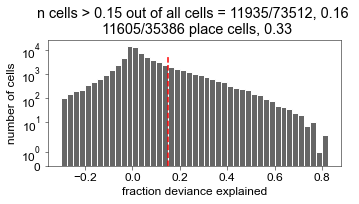

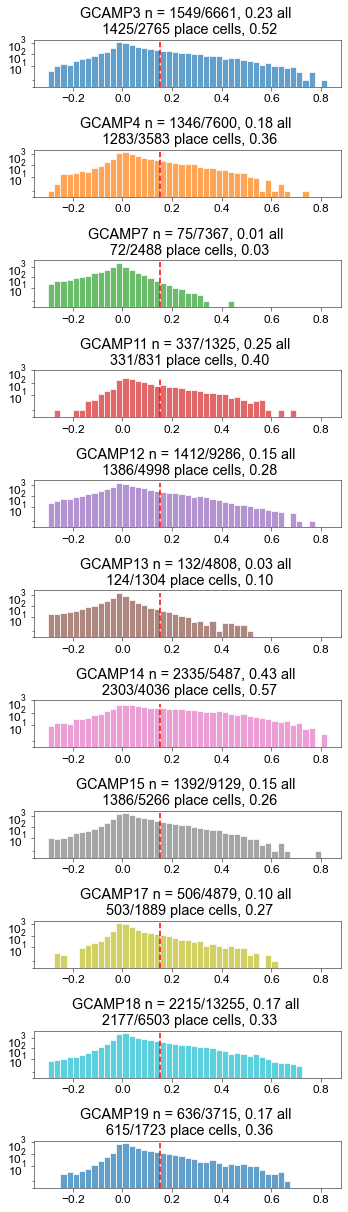

In [38]:
from matplotlib.ticker import LogLocator
fig, ax = plt.subplots(figsize=(5,3))

ax.hist(df_glm_FDE['FDE_full_model'], bins=np.arange(-0.3,0.85,0.025), facecolor=(0.4, 0.4, 0.4));
ax.vlines(frac_dev_thr, 0, 6000, linestyle='--', color='red')
ax.set_yscale('symlog')
ax.set_title('n cells > %.2f out of all cells = %d/%d, %.2f \n %d/%d place cells, %.2f' % (frac_dev_thr, 
                                                          np.sum(df_glm_FDE['FDE_full_model']>frac_dev_thr),
                                                          df_glm_FDE['FDE_full_model'].shape[0],
                                                          (np.sum(df_glm_FDE['FDE_full_model']>frac_dev_thr) /
                                                          df_glm_FDE['FDE_full_model'].shape[0]),                                 
                                                          np.sum(df_glm_FDE['FDE_full_model'][df_glm_FDE['is_place_cell']]>frac_dev_thr),
                                                          np.sum(df_glm_FDE['is_place_cell']),
                                                                                           (np.sum(df_glm_FDE['FDE_full_model'][df_glm_FDE['is_place_cell']]>frac_dev_thr)/
                                                          np.sum(df_glm_FDE['is_place_cell']) )
                                                         )
            )
ax.set_ylabel('number of cells')
ax.set_xlabel('fraction deviance explained')
ax.set_clip_box([[ax.get_xlim()[0], ax.get_xlim()[1]], 
                           [ax.get_ylim()[0], ax.get_ylim()[1]]])
# ax.yaxis.set_major_locator(LogLocator())

save_figures = False
if save_figures:
    description = '-'.join(all_predictors)  + '_sensor-correct'
    pt.savefig(fig, fig_dir, "%s_expday%s_GLM_FDE-full-model_allCells_%s_log" % (
                ut.make_anim_tag(include_ans),ut.make_day_tag(exp_days),description)
                   )
    
fig, ax = plt.subplots(len(include_ans), 1, figsize=(5,17))

clrs= pt.get_anim_colors(len(include_ans))
for an_i, an in enumerate(include_ans):
    this_an_FDE = df_glm_FDE['FDE_full_model'][df_glm_FDE['mouse']==an]
    ax[an_i].hist(this_an_FDE, bins=np.arange(-0.3,0.85,0.025), facecolor=clrs[an_i], alpha=0.7);
    ax[an_i].vlines(frac_dev_thr, 0, ax[an_i].get_ylim()[1], linestyle='--', color='red') 
    ax[an_i].set_title('%s n = %d/%d, %.2f all \n %d/%d place cells, %.2f' % (an, 
                                                          np.sum(this_an_FDE>frac_dev_thr),
                                                          this_an_FDE.shape[0],
                                                          (np.sum(this_an_FDE>frac_dev_thr) /
                                                          this_an_FDE.shape[0]),                                 
                                                          np.sum(this_an_FDE[df_glm_FDE['is_place_cell'][df_glm_FDE['mouse']==an]]>frac_dev_thr),
                                                          np.sum(df_glm_FDE['is_place_cell'][df_glm_FDE['mouse']==an]),
                                                                                           (np.sum(this_an_FDE[df_glm_FDE['is_place_cell'][df_glm_FDE['mouse']==an]]>frac_dev_thr)/
                                                          np.sum(df_glm_FDE['is_place_cell'][df_glm_FDE['mouse']==an]) )
                                                          ))
    ax[an_i].set_yscale('symlog')
    ax[an_i].set_yticks([10**1, 10**2, 10**3])
    
save_figures = False
if save_figures:
    description = '-'.join(all_predictors)
    pt.savefig(fig, fig_dir, "%s_expday%s_GLM_FDE-full-model_indivAn_%s_log" % (
                ut.make_anim_tag(include_ans),ut.make_day_tag(exp_days),description)
                   )

### Plot distribution of FED (relative contribution) per population
Fig. 7d

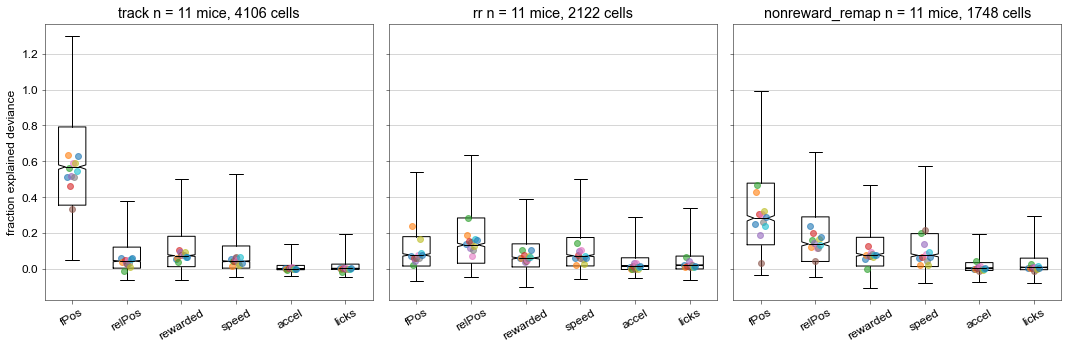

In [39]:
fig, ax = plt.subplots(1, 3, figsize=(15, 5), sharey=True)
ax[0].set_ylabel('fraction explained deviance')

celltypes = ['track', 'rr', 'nonreward_remap']
clrs = pt.get_anim_colors(len(include_ans))
jitter = np.linspace(-0.1,0.1,len(include_ans))

for t_i, t in enumerate(celltypes):
    data_to_plot = df_glm[df_glm['celltype']==t]
    for var_i, var in enumerate(var_plot_order):
        var_id = all_var.index(var)   
 
        # Distribution across cells as a boxplot
        box_fed = ax[t_i].boxplot(data_to_plot['FED_'+var].values,
                                    positions=[var_i],
                                  whis = (2.5, 97.5),
                                  showfliers=False,
                                  notch=True,
                                  widths=0.5,
                                  bootstrap = 10000,
                                    )  
        # Plot individual medians per mouse as colored dots
        box_fed['medians'][0].set(color = 'k')
        for an_i,an in enumerate(include_ans):
            this_median = np.median(data_to_plot[
                data_to_plot['mouse']==an
            ]['FED_'+var].values)
            ax[t_i].plot(var_i+jitter[an_i],this_median, 'o', color=clrs[an_i], alpha=0.6)
        # box_fed['medians'][0].set(color = 'k')
    ax[t_i].set_xticks(range(len(var_plot_order)))
    ax[t_i].set_xticklabels(var_plot_order, rotation=30)
    n_anim = len(np.unique(data_to_plot['mouse']))
    n_cells = data_to_plot.shape[0]
    ax[t_i].set_title("%s n = %d mice, %d cells" % (t,n_anim,n_cells))
    ax[t_i].grid('major', axis='y')
    
save_figures = False

if save_figures:    
    description = '-'.join(all_predictors)  + '_sensor-correct'
    pt.savefig(fig, fig_dir, "%s_expday%s_GLM_Predictor-FED-boxPlot_allCells_%s" % (
                ut.make_anim_tag(include_ans),ut.make_day_tag(exp_days),description)
                   )

## Find fraction of cells in each type with each var as their top, second-top, and bottom predictor

Pie charts for Fig. 7e and Ext. Fig. 9

In [46]:
frac_max_var = pd.DataFrame(index=['track','rr','nonreward_remap'],
                                columns=var_plot_order)
frac_min_var = pd.DataFrame(index=['track','rr','nonreward_remap'],
                                columns=var_plot_order)


for t_i, t in enumerate(celltypes):
    data_to_plot = df_glm[df_glm['celltype']==t]
    # sorted_data_to_plot = np.argsort(data_to_plot[['FED_fPos', 'FED_relPos', 'FED_rewarded',
    #    'FED_speed', 'FED_accel', 'FED_licks']], axis=1, kind='stable')
    max_var = data_to_plot[['FED_fPos', 'FED_relPos', 'FED_rewarded',
       'FED_speed', 'FED_accel', 'FED_licks']].idxmax(axis=1)
    min_var = data_to_plot[['FED_fPos', 'FED_relPos', 'FED_rewarded',
       'FED_speed', 'FED_accel', 'FED_licks']].idxmin(axis=1)
    for var_i, var in enumerate(var_plot_order):
        var_id = all_var.index(var) 
   
        frac_max_var.loc[t][var] = np.sum(max_var==('FED_'+var)) / len(max_var)
        frac_min_var.loc[t][var] = np.sum(min_var==('FED_'+var)) / len(min_var)
        
        data_this_max_var = data_to_plot.loc[max_var==('FED_'+var)]['FED_'+var]


In [47]:
# Set teal to brown color map
from matplotlib.colors import ListedColormap
use_cm = ListedColormap(cm.BrBG_r(np.linspace(0.15,0.85,len(all_var))))

/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/pandas/plotting/_matplotlib/core.py:1547: MatplotlibDeprecationWarning: normalize=None does not normalize if the sum is less than 1 but this behavior is deprecated since 3.3 until two minor releases later. After the deprecation period the default value will be normalize=True. To prevent normalization pass normalize=False 
  results = ax.pie(y, labels=blabels, **kwds)


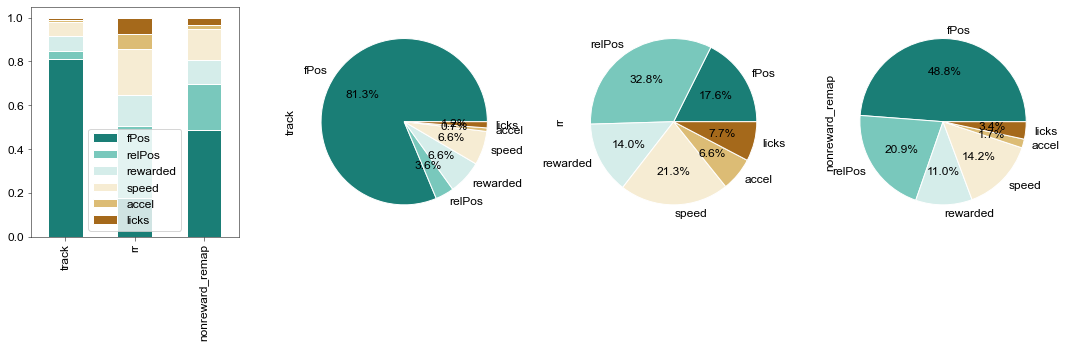

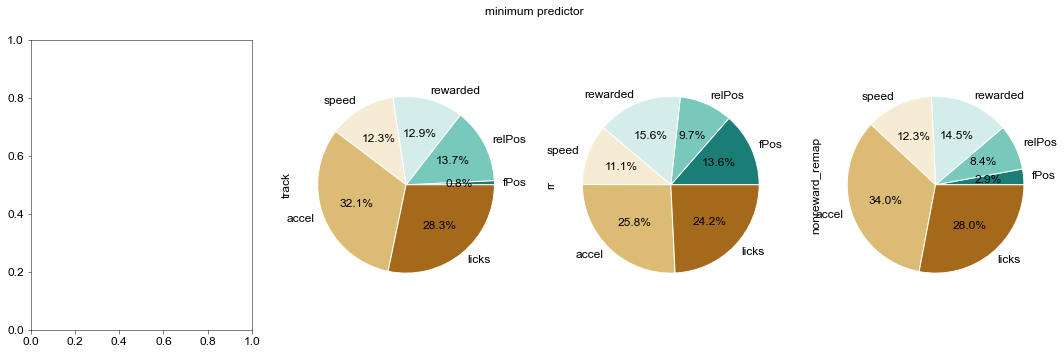

In [48]:
fig,ax = plt.subplots(1,4, figsize=(15,5))
fig_min,ax_min = plt.subplots(1,4, figsize=(15,5))
fig_min.suptitle('minimum predictor')

frac_max_var.plot(kind='bar', stacked=True, ax=ax[0], colormap=use_cm)

for t_i,t in enumerate(celltypes):
    frac_max_var.loc[t].plot(kind='pie', subplots=True, ax=ax[t_i+1], autopct='%1.1f%%', colormap=use_cm)
    frac_min_var.loc[t].plot(kind='pie', subplots=True, ax=ax_min[t_i+1], autopct='%1.1f%%', colormap=use_cm)
                 
save_figures = False
if save_figures:
    description = '-'.join(all_predictors)  + '_sensor-correct'
    pt.savefig(fig, fig_dir, "%s_expday%s_GLM_TopPredictor-FED-Pies_bar_allCells_%s" % (
                ut.make_anim_tag(include_ans),ut.make_day_tag(exp_days),description)
                   )
    pt.savefig(fig_min, fig_dir, "%s_expday%s_GLM_BottomPredictor-FED-Pies_bar_allCells_%s" % (
                ut.make_anim_tag(include_ans),ut.make_day_tag(exp_days),description)
                   )

In [49]:
sort_order = ['FED_relPos', 'FED_speed', 'FED_fPos','FED_rewarded','FED_licks','FED_accel']
data_to_plot = df_glm[df_glm['celltype']=='rr']
sorted_data_to_plot = data_to_plot.sort_values(sort_order, ascending=False)
max_var = sorted_data_to_plot[['FED_fPos', 'FED_relPos', 'FED_rewarded',
       'FED_speed', 'FED_accel', 'FED_licks']].idxmax(axis=1)
for index, col in zip(max_var.index, max_var.values):
    this_entry = sorted_data_to_plot.loc[
        index, ['FED_fPos', 'FED_relPos', 'FED_rewarded', 'FED_speed', 'FED_accel', 'FED_licks']]
    sorted_data_to_plot.loc[index, ['FED_fPos', 'FED_relPos', 'FED_rewarded', 'FED_speed', 'FED_accel', 'FED_licks']]  = (this_entry -
                                                                                                                          np.nanmin(this_entry)) / \
    (sorted_data_to_plot.loc[index,col] - np.nanmin(this_entry))


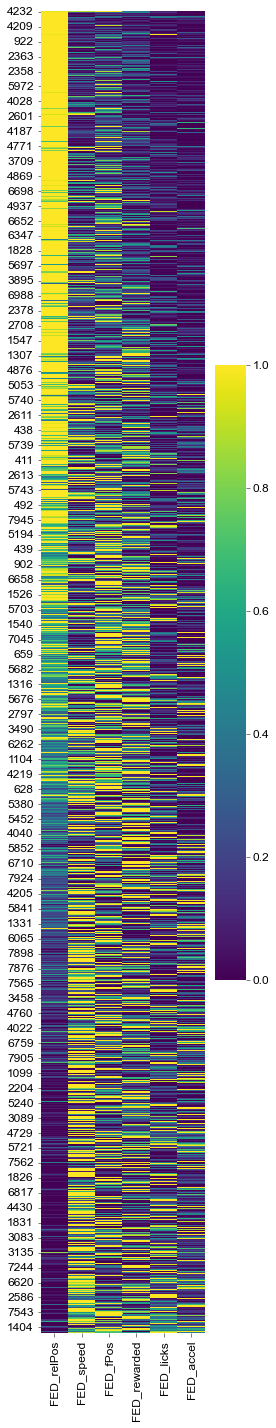

In [50]:
## Plot all cells's FED normalized by their top predictor, sorted by FED of reward-relative pos
## to show the mixed selectivity gradient
fig, ax = plt.subplots(figsize=[4,20])
sns.heatmap(sorted_data_to_plot[sort_order], cmap='viridis') #robust=True, 
save_figures = False
if save_figures:

    description = '-'.join(all_predictors)
    pt.savefig(fig, fig_dir, "%s_expday%s_GLM_PredictorHeatmap_sortby-relPos-val_RR_%s" % (
                ut.make_anim_tag(include_ans),ut.make_day_tag(exp_days),description)
                   )

In [56]:
## plot FED distributions for top 2 predictors, relPos and speed, and get the second top predictors

df_glm['top'] = np.zeros((len(df_glm),))*np.nan
df_glm['second'] = np.zeros((len(df_glm),))*np.nan

var_plot_order = ['fPos', 'relPos', 'rewarded', 'speed', 'accel', 'licks']

FED_var = ['FED_fPos', 'FED_relPos', 'FED_rewarded',
   'FED_speed', 'FED_accel', 'FED_licks']

all_frac_second_max_var = pd.DataFrame(
                                columns=['celltype',
                                         'top_predictor',
                                         'fPos',
                                         'relPos',
                                         'rewarded',
                                         'speed',
                                         'accel',
                                         'licks',])

for ct in ['rr','track','nonreward_remap']:

    data_to_plot = df_glm[df_glm['celltype']==ct]
    # identify the top predictor for each cell in data_to_plot
    max_var = data_to_plot[FED_var].idxmax(axis=1)
    min_var = data_to_plot[FED_var].idxmin(axis=1)
    df_glm['top'].iloc[max_var.index] = max_var.values
    # For each top predictor of RR cells, plot the pie chart of 2nd place predictor
    for top_var_i, top_var in enumerate(var_plot_order): #['relPos','speed']):

        # Get a dataframe for all cells with this top predictor
        data_this_max_var = data_to_plot.loc[max_var==('FED_'+top_var)]

        # Split so each cell has a duplicate entry for each predictor name 
        # len will be len(data_this_max_var)*len(all_var)
        sub_df = data_this_max_var.melt(id_vars = ['mouse','day','cell_inds','celltype'], 
                                    value_vars=['FED_fPos', 'FED_relPos', 'FED_rewarded',
           'FED_speed', 'FED_accel', 'FED_licks'], var_name='predictor',value_name='FED' )

        remaining_var = np.array(FED_var)[np.array(FED_var) != 'FED_'+top_var].tolist()
        # axis=1 finds the top now that we've excluded the first predictor
        second_max_var = data_this_max_var[remaining_var].idxmax(axis=1) 
        
        # pandas kindly keeps the original index for us
        df_glm['second'].iloc[second_max_var.index] = second_max_var.values
        
        frac_second_max_var = pd.DataFrame(index=[0],
                                    columns=['celltype',
                                             'top_predictor',
                                             'fPos',
                                             'relPos',
                                             'rewarded',
                                             'speed',
                                             'accel',
                                             'licks',])

        frac_second_max_var['celltype'] = ct
        frac_second_max_var['top_predictor'] = top_var
        for rvar in remaining_var:
            frac_second_max_var[rvar.split('_')[-1]] = np.sum(second_max_var==(rvar)) / len(second_max_var)

        # frac_second_max_var.iloc[0][var_plot_order].plot(kind='pie', subplots=True, 
        #                                                  ax=ax3[top_var_i], autopct='%1.1f%%', colormap=use_cm) #'%1.1f%%'

       
        all_frac_second_max_var = all_frac_second_max_var.append(frac_second_max_var, ignore_index=True)

 

/home/mari/anaconda3/envs/dope2p_rr/lib/python3.8/site-packages/pandas/core/indexing.py:670: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  iloc._setitem_with_indexer(indexer, value)


In [57]:
all_frac_second_max_var = all_frac_second_max_var.melt(id_vars = ['celltype','top_predictor'], 
                                value_vars=var_plot_order, 
                             var_name='second_predictor',
                             value_name='fraction of cell subset' )

In [58]:
all_frac_second_max_var

,celltype,top_predictor,second_predictor,fraction of cell subset
0,rr,fPos,fPos,NaN
1,rr,relPos,fPos,0.377331
2,rr,rewarded,fPos,0.271812
3,rr,speed,fPos,0.201774
4,rr,accel,fPos,0.0935252
...,...,...,...,...
103,nonreward_remap,relPos,licks,0.0739726
104,nonreward_remap,rewarded,licks,0.078125
105,nonreward_remap,speed,licks,0.0963855
106,nonreward_remap,accel,licks,0.166667


### Plot the bar plots in Ext. Fig. 9d

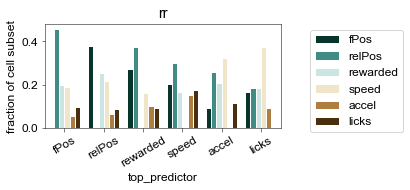

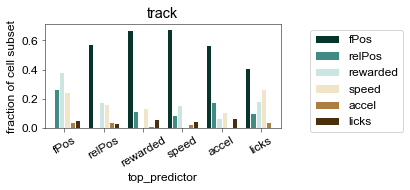

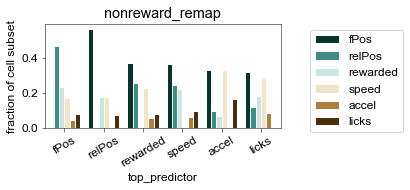

In [60]:
pie_palette = sns.color_palette(cm.BrBG_r(np.linspace(
    0,1,len(all_var))))

for ct in ['rr', 'track', 'nonreward_remap']:
    fig, ax = plt.subplots(figsize=[6,2.8])
    sns.barplot(data=all_frac_second_max_var[all_frac_second_max_var['celltype']==ct],
                x = 'top_predictor',
                y= 'fraction of cell subset', 
                hue = 'second_predictor',
                errorbar=None, palette=pie_palette)
    ax.tick_params(axis='x', rotation=30)
    ax.set_title(ct)
    ax.legend(loc='upper left',bbox_to_anchor=(1.1, 1))
    save_figures = False
    if save_figures:

        description = '-'.join(all_predictors)  + '_sensor-correct'
        pt.savefig(fig, fig_dir, "%s_expday%s_GLM_%s-SecondTopPredictors_GroupedBar_%s" % (
                    ut.make_anim_tag(include_ans),ut.make_day_tag(exp_days),ct,description)
                       )

#### Compute final percentage of cells that have RR as top or second predictor

In [61]:
print(len(df_glm[df_glm['celltype']=='rr']))
# recall this is the percentage RR cells well-fit by the GLM
len(df_glm[df_glm['celltype']=='rr']) / all_is_rr.shape[0]

2122


0.3549088476333835

In [63]:
print("---RR---")
print("fraction of RR cells fit by GLM with RR as top predictor:", len(
    df_glm[(
        (df_glm['celltype']=='rr') & (df_glm['top']=='FED_relPos'))]) / len(df_glm[df_glm['celltype']=='rr']))
print("fraction of RR cells fit by GLM with RR as top OR second predictor:", len(
    df_glm[(
        (df_glm['celltype']=='rr') & (
    (df_glm['top']=='FED_relPos') | (df_glm['second']=='FED_relPos')))]) / len(df_glm[df_glm['celltype']=='rr']))
print("fraction of all RR cells with RR as top predictor:", len(
    df_glm[(
        (df_glm['celltype']=='rr') & (df_glm['top']=='FED_relPos'))]) / all_is_rr.shape[0])
print("fraction of all RR cells with RR as top OR second predictor:", len(
    df_glm[(
        (df_glm['celltype']=='rr') & (
    (df_glm['top']=='FED_relPos') | (df_glm['second']=='FED_relPos')))]) / all_is_rr.shape[0])
print("fraction of all place cells with RR as top predictor:", len(
    df_glm[(
        (df_glm['top']=='FED_relPos'))]) / np.sum(df_glm_FDE['is_place_cell']))
print("fraction of all place cells with RR as top OR second predictor:", len(
    df_glm[(
    (df_glm['top']=='FED_relPos') | (df_glm['second']=='FED_relPos'))]) / np.sum(df_glm_FDE['is_place_cell']))


---RR---
fraction of RR cells fit by GLM with RR as top predictor: 0.3284637134778511
fraction of RR cells fit by GLM with RR as top OR second predictor: 0.556550424128181
fraction of all RR cells with RR as top predictor: 0.11657467803980599
fraction of all RR cells with RR as top OR second predictor: 0.19752466967720356
fraction of all place cells with RR as top predictor: 0.0342225738992822
fraction of all place cells with RR as top OR second predictor: 0.08947041202735545


In [64]:
print("---TR---")
print("fraction of TR cells fit by GLM with POS as top predictor:", len(
    df_glm[(
        (df_glm['celltype']=='track') & (df_glm['top']=='FED_fPos'))]) / len(df_glm[df_glm['celltype']=='track']))
print("fraction of TR cells fit by GLM with POS as top OR second predictor:", len(
    df_glm[(
        (df_glm['celltype']=='track') & (
    (df_glm['top']=='FED_fPos') | (df_glm['second']=='FED_fPos')))]) / len(df_glm[df_glm['celltype']=='track']))
print("fraction of all TR cells with POS as top predictor:", len(
    df_glm[(
        (df_glm['celltype']=='track') & (df_glm['top']=='FED_fPos'))]) / all_is_track.sum())
print("fraction of all TR cells with POS as top OR second predictor:", len(
    df_glm[((df_glm['celltype']=='track') & (
    (df_glm['top']=='FED_fPos') | (df_glm['second']=='FED_fPos')))]) / all_is_track.sum())
print("fraction of all place cells with POS as top predictor:", len(
    df_glm[(
        (df_glm['top']=='FED_fPos'))]) / np.sum(df_glm_FDE['is_place_cell']))
print("fraction of all place cells with POS as top OR second predictor:", len(
    df_glm[(
    (df_glm['top']=='FED_fPos') | (df_glm['second']=='FED_fPos'))]) / np.sum(df_glm_FDE['is_place_cell']))


---TR---
fraction of TR cells fit by GLM with POS as top predictor: 0.8129566488066244
fraction of TR cells fit by GLM with POS as top OR second predictor: 0.9315635655138821
fraction of all TR cells with POS as top predictor: 0.47502490394193825
fraction of all TR cells with POS as top OR second predictor: 0.5443290166500641
fraction of all place cells with POS as top predictor: 0.12900582151133216
fraction of all place cells with POS as top OR second predictor: 0.16746735997287063
